# 3. Machine Learning for Classification
We'll use logistic regression to predict churn

3.1 Churn Prediction Project¶
- Dataset: [Link](https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv)

# 3.2 Data preparation

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

In [62]:
# Paths
base_path = Path.cwd()
file_path = base_path / "data" / "data.csv"
df = pd.read_csv(file_path)

In [63]:
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               1334 non-null   str    
 1   industry                  1328 non-null   str    
 2   number_of_courses_viewed  1462 non-null   int64  
 3   annual_income             1281 non-null   float64
 4   employment_status         1362 non-null   str    
 5   location                  1399 non-null   str    
 6   interaction_count         1462 non-null   int64  
 7   lead_score                1462 non-null   float64
 8   converted                 1462 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 102.9 KB


# 3.3 EDA

### Missing Values

In [65]:
categorical_columns = list(df.dtypes[df.dtypes == 'str'].index)

In [66]:
numerical_columns = list(df.dtypes[df.dtypes != 'str'].index)

In [67]:
df[categorical_columns].isnull().sum()

lead_source          128
industry             134
employment_status    100
location              63
dtype: int64

In [68]:
df[categorical_columns].nunique()

lead_source          5
industry             7
employment_status    4
location             7
dtype: int64

In [69]:
df[numerical_columns].isnull().sum()

number_of_courses_viewed      0
annual_income               181
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [70]:
list(df.columns)

['lead_source',
 'industry',
 'number_of_courses_viewed',
 'annual_income',
 'employment_status',
 'location',
 'interaction_count',
 'lead_score',
 'converted']

<Axes: xlabel='industry'>

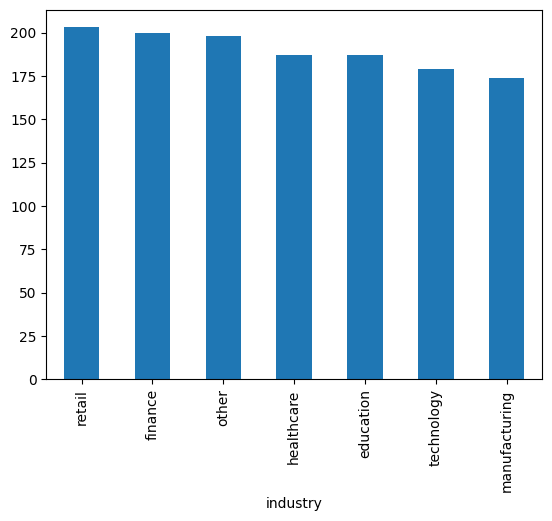

In [71]:
df.industry.value_counts().plot(kind='bar') # value_counts() becoz its var is categorical

Retail is the most frequent observation (mode) 

### Correlation Matrix

In [72]:
df_numeric = df.copy()

In [73]:
df_numeric = df_numeric[numerical_columns].drop(columns=['converted'])

In [74]:
df_numeric.describe()

,number_of_courses_viewed,annual_income,interaction_count,lead_score
count,1462.000000,1281.000000,1462.000000,1462.000000
mean,2.031464,59886.273224,2.976744,0.506108
std,1.449717,15070.140389,1.681564,0.288465
min,0.000000,13929.000000,0.000000,0.000000
25%,1.000000,49698.000000,2.000000,0.262500
50%,2.000000,60148.000000,3.000000,0.510000
75%,3.000000,69639.000000,4.000000,0.750000
max,9.000000,109899.000000,11.000000,1.000000


In [75]:
df_numeric.corr()

,number_of_courses_viewed,annual_income,interaction_count,lead_score
number_of_courses_viewed,1.000000,0.031551,-0.023565,-0.004879
annual_income,0.031551,1.000000,0.048618,0.005334
interaction_count,-0.023565,0.048618,1.000000,0.009888
lead_score,-0.004879,0.005334,0.009888,1.000000


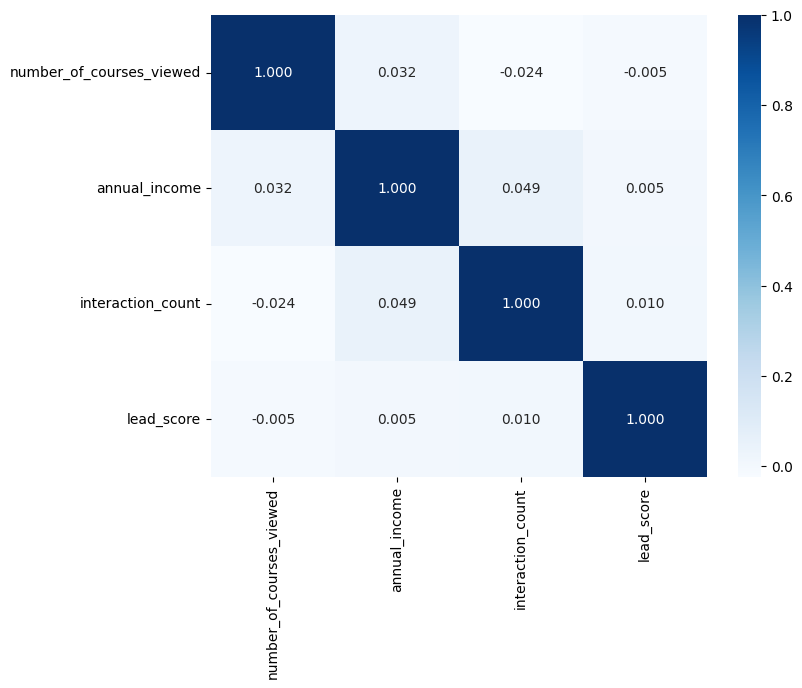

In [76]:
corr = df_numeric.corr() #remove target variable

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.3f')
plt.show()

`annual_income` and `interaction_count`, are the two features that have the biggest correlation

In [77]:
corr.unstack().sort_values(ascending=False)

number_of_courses_viewed  number_of_courses_viewed    1.000000
annual_income             annual_income               1.000000
lead_score                lead_score                  1.000000
interaction_count         interaction_count           1.000000
annual_income             interaction_count           0.048618
interaction_count         annual_income               0.048618
annual_income             number_of_courses_viewed    0.031551
number_of_courses_viewed  annual_income               0.031551
lead_score                interaction_count           0.009888
interaction_count         lead_score                  0.009888
annual_income             lead_score                  0.005334
lead_score                annual_income               0.005334
                          number_of_courses_viewed   -0.004879
number_of_courses_viewed  lead_score                 -0.004879
                          interaction_count          -0.023565
interaction_count         number_of_courses_viewed   -0

# 3.4 Setting up the validation framework

<div style="margin-left: 0; text-align: left; font-family: Arial, sans-serif;">

<h3>Dataset Split Workflow</h3>

<div style="display: flex; width: 720px; border: 2px solid black; height: 70px; margin-bottom: 20px;">
  <div style="width: 60%; border-right: 2px solid black; display: flex; align-items: center; justify-content: center; font-size: 20px;">
    <b>TRAIN (60%)</b>
  </div>
  <div style="width: 20%; border-right: 2px solid black; display: flex; align-items: center; justify-content: center; font-size: 20px;">
    <b>VAL (20%)</b>
  </div>
  <div style="width: 20%; display: flex; align-items: center; justify-content: center; font-size: 20px;">
    <b>TEST (20%)</b>
  </div>
</div>

<p style="font-size: 16px; margin: 8px 0;"><b>Step 1:</b> Split dataset into Train / Validation / Test</p>

<div style="font-size: 28px; margin: 8px 0;">↓</div>

<div style="display: flex; align-items: center; gap: 20px; margin-bottom: 20px;">
  <div style="width: 576px; border: 2px solid #1f77b4; height: 70px; display: flex; align-items: center; justify-content: center; font-size: 20px;">
    <b>FULL TRAIN = TRAIN + VAL (80%)</b>
  </div>
  <div style="width: 144px; border: 2px solid black; height: 70px; display: flex; align-items: center; justify-content: center; font-size: 20px;">
    <b>TEST (20%)</b>
  </div>
</div>

<p style="font-size: 16px; margin: 8px 0;"><b>Step 2:</b> After tuning on validation, merge Train + Validation into Full Train</p>

<div style="font-size: 28px; margin: 8px 0;">↓</div>

<div style="display: flex; gap: 20px; margin-bottom: 20px;">
  <div style="width: 432px; border: 2px solid black; height: 65px; display: flex; align-items: center; justify-content: center; font-size: 18px;">
    <b>TRAIN (60%)</b>
  </div>
  <div style="width: 144px; border: 2px solid black; height: 65px; display: flex; align-items: center; justify-content: center; font-size: 18px;">
    <b>VAL (20%)</b>
  </div>
</div>

<p style="font-size: 16px; margin: 8px 0;"><b>Inside Full Train:</b> Validation is <b>20% / 80% = 25%</b> of Full Train</p>

<hr style="margin: 20px 0;">

<p style="font-size: 16px;">
<b>Workflow:</b><br>
1. Train on <b>Train</b><br>
2. Tune on <b>Validation</b><br>
3. Retrain final model on <b>Full Train = Train + Validation</b><br>
4. Evaluate once on <b>Test</b>
</p>

</div>

In [78]:
from sklearn.model_selection import train_test_split

In [79]:
SEED = 42

In [80]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=SEED)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=SEED)

In [81]:
assert len(df) == (len(df_train) + len(df_val) + len(df_test))

In [82]:
len(df_train), len(df_val), len(df_test)

(876, 293, 293)

In [83]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [84]:
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

# 3.5 Feature importance: Mutual information (categorical variables)

In [85]:
from sklearn.metrics import mutual_info_score, accuracy_score

In [86]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_train.converted)

In [87]:
df_mi = df_train[categorical_columns].fillna('NA').apply(mutual_info_churn_score)

In [88]:
df_mi = df_mi.sort_values(ascending=False).to_frame(name='MI')
df_mi

,MI
lead_source,0.035396
employment_status,0.012938
industry,0.011575
location,0.004464


`lead_source` has the biggest score.

In [89]:
df_train = df_train.drop('converted', axis=1)
df_val = df_val.drop('converted', axis=1)
df_test = df_test.drop('converted', axis=1)

assert 'converted' not in df_train.columns
assert 'converted' not in df_val.columns
assert 'converted' not in df_test.columns

### Missing Values

In [90]:
numerical_columns.remove('converted') # removed target variable from numerical features

In [91]:
df_train[categorical_columns] = df_train[categorical_columns].fillna('NA')

In [92]:
df_train[numerical_columns] = df_train[numerical_columns].fillna(0)

In [93]:
df_val[categorical_columns] = df_val[categorical_columns].fillna('NA')

In [94]:
df_val[numerical_columns] = df_val[numerical_columns].fillna(0)

# 3.6 One-hot encoding
- Use Scikit-Learn to encode categorical features

In [95]:
from sklearn.feature_extraction import DictVectorizer

In [96]:
train_dict = df_train.to_dict(orient='records') 

In [97]:
dv = DictVectorizer(sparse=False) # sparse set to false to use np array matrix
X_train = dv.fit_transform(train_dict) # training set

In [98]:
dv.get_feature_names_out()

array(['annual_income', 'employment_status=NA',
       'employment_status=employed', 'employment_status=self_employed',
       'employment_status=student', 'employment_status=unemployed',
       'industry=NA', 'industry=education', 'industry=finance',
       'industry=healthcare', 'industry=manufacturing', 'industry=other',
       'industry=retail', 'industry=technology', 'interaction_count',
       'lead_score', 'lead_source=NA', 'lead_source=events',
       'lead_source=organic_search', 'lead_source=paid_ads',
       'lead_source=referral', 'lead_source=social_media', 'location=NA',
       'location=africa', 'location=asia', 'location=australia',
       'location=europe', 'location=middle_east',
       'location=north_america', 'location=south_america',
       'number_of_courses_viewed'], dtype=object)

In [99]:
X_train.shape

(876, 31)

In [100]:
X_train

array([[5.8472e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [7.1738e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        3.0000e+00],
       [8.1973e+04, 0.0000e+00, 1.0000e+00, ..., 1.0000e+00, 0.0000e+00,
        3.0000e+00],
       ...,
       [8.9042e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        3.0000e+00],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        1.0000e+00],
       [5.0259e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        4.0000e+00]], shape=(876, 31))

In [101]:
val_dict = df_val.to_dict(orient='records')

In [102]:
# why tranform only? Validation must use the same feature columns learned from train. 
# which is already fitted
X_val = dv.transform(val_dict)

# 3.9 Training logistic regression

In [103]:
from sklearn.linear_model import LogisticRegression

In [104]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [105]:
y_pred = model.predict(X_val) 

In [106]:
original_score = accuracy_score(y_val, y_pred)

In [107]:
original_score

0.6996587030716723

In [108]:
# accuray on the validation dataset
accuracy = np.round(original_score, 2)
print(f'Accuracy = {accuracy}')

Accuracy = 0.7


# 3.10 Feature Elimination Techniques

In [109]:
feature_names = dv.get_feature_names_out()
scores = {}

for col in range(X_train.shape[1]):
    X_train_drop = X_train.copy()
    X_val_drop = X_val.copy()
    
    X_train_drop = np.delete(X_train_drop, col, axis=1)
    X_val_drop = np.delete(X_val_drop, col, axis=1)

    model.fit(X_train_drop, y_train)
    y_pred = model.predict(X_val_drop) 

    score = accuracy_score(y_val, y_pred)
    delta = score - original_score
    
    scores[ feature_names[col] ] = score

    print(f"feature dropped:{feature_names[col]:<30}  | Accuracy:{score:.4f}  | Delta:{delta:+.4f}")
   
    

feature dropped:annual_income                   | Accuracy:0.8532  | Delta:+0.1536
feature dropped:employment_status=NA            | Accuracy:0.6997  | Delta:+0.0000
feature dropped:employment_status=employed      | Accuracy:0.6997  | Delta:+0.0000
feature dropped:employment_status=self_employed  | Accuracy:0.6997  | Delta:+0.0000
feature dropped:employment_status=student       | Accuracy:0.6997  | Delta:+0.0000
feature dropped:employment_status=unemployed    | Accuracy:0.6962  | Delta:-0.0034
feature dropped:industry=NA                     | Accuracy:0.6997  | Delta:+0.0000
feature dropped:industry=education              | Accuracy:0.6997  | Delta:+0.0000
feature dropped:industry=finance                | Accuracy:0.6997  | Delta:+0.0000
feature dropped:industry=healthcare             | Accuracy:0.6997  | Delta:+0.0000
feature dropped:industry=manufacturing          | Accuracy:0.6997  | Delta:+0.0000
feature dropped:industry=other                  | Accuracy:0.6997  | Delta:+0.0000
fea

### How to interpret delta
- Negative delta → dropping the feature made performance worse → feature is useful
- Positive delta → dropping the feature made performance better → feature may be noisy / less useful
- Near zero → feature likely has little impact

Least useful feature: `annual_income` while `industry` has no impact.

In [110]:
max(scores, key=scores.get)

'annual_income'

# 3.11 Training Regularized Regression

In [113]:
scores = {}

for C in [0.01, 0.1, 1, 10, 100]:
    model = LogisticRegression( C=C, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    score = accuracy_score(y_val, y_pred)
    scores[C] = round(score, 3)

    print(f'C = {C}:\t Accuracy = {score:.4f}')
    

C = 0.01:	 Accuracy = 0.8123
C = 0.1:	 Accuracy = 0.8430


C:\Users\alann\anaconda3\envs\ml-zoomcamp-churn\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C = 1:	 Accuracy = 0.8532


C:\Users\alann\anaconda3\envs\ml-zoomcamp-churn\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C = 10:	 Accuracy = 0.8532
C = 100:	 Accuracy = 0.8532


In [114]:
scores

{0.01: 0.812, 0.1: 0.843, 1: 0.853, 10: 0.853, 100: 0.853}

In [115]:
print(f'The best `C` is {max(scores, key=scores.get)}.')

The best `C` is 1.
